# Prevalence check: Figure 4C, D and Supporting Figure 5E–H

Copy of `quinlan-lab/constraint-tools` `papers/neutral_models_are_biased/11.compare-lax-with-stringent-truth-set.ipynb` at commit `4063cdc118`, edited to measure the positive-class fraction π alongside every normalized auPRC, and to add auROC, which does not depend on π.

Every edit is marked `# PREVALENCE CHECK`; nothing else differs from the original. Outputs were cleared, since they belong to the unedited code. See `README.md` in this directory for what each result settles.


## Setup

c.f., https://docs.google.com/presentation/d/1qw3QiWVHSqYA2f4QoahE8FHZPisIftp-tCUWTODjnDY/edit#slide=id.g279e2683f04_0_0

In [1]:
import matplotlib.pyplot as plt

# Set the font family to Arial
# https://g.co/gemini/share/3898a74b2d77
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial'] # Add Arial to the sans-serif list

plt.rcParams.update({
    'font.size': 20,
})

In [2]:
CONSTRAINT_TOOLS = '/scratch/ucgd/lustre-labs/quinlan/u6018199/constraint-tools'
CONSTRAINT_TOOLS_DATA = '/scratch/ucgd/lustre-labs/quinlan/data-shared/constraint-tools'

In [3]:
THRESHOLD_BIN_SIZE = 500

In [4]:
import pandas as pd

FEATURE_GC_CONTENT = 'GC_content_1000bp'
FEATURE_BGS = 'B'
FEATURE_GBGC = 'B_M1star.EUR'

FEATURE_BINS_GC_CONTENT = pd.IntervalIndex.from_tuples([(0.2, 0.375), (0.4, 0.7)])
FEATURE_BINS_BGS = pd.IntervalIndex.from_tuples([(0.5, 0.76), (0.9, 1.0)])
FEATURE_BINS_GBGC = pd.IntervalIndex.from_tuples([(-0.3, 0.2), (0.4, 1.2)])

## Stringent truth set

c.f., papers/neutral_models_are_biased/8.labeled-enhancers/main.3.ipynb

In [5]:
import polars as pl

def get_stringent_truth_set(): 
    df = pl.read_csv(
        f'{CONSTRAINT_TOOLS_DATA}/stringent_truth_set/truth-set.gnocchi.lambda_s.depletion_rank.CDTS.bed',
        separator='\t',
    )
    df = df.to_pandas()
    return df 
    
STRINGENT_WINDOWS = get_stringent_truth_set()
STRINGENT_WINDOWS

     chromosome     start       end   gnocchi  truly constrained      B  \
0          chr1   2128961   2129161  6.530123               True  0.841   
1          chr1   2268561   2268761  5.007183               True  0.847   
2          chr1   6240740   6241540  3.309271               True  0.872   
3          chr1   6483340   6483540  3.687737               True  0.837   
4          chr1   6697340   6697540  1.642701               True  0.708   
...         ...       ...       ...       ...                ...    ...   
4928       chr6  46411000  46412000  0.025313              False  0.842   
4929       chr6  82997000  82998000 -0.291330              False  0.732   
4930       chr1  30222000  30223000  0.489599              False  0.953   
4931       chr9  38203000  38204000  2.216012              False  0.782   
4932      chr15  25084000  25085000  0.388432              False  0.898   

      B_M1star.EUR  GC_content_1000bp  lambda_s  \
0         0.347981           0.585415  0.117883 

Text(0.5, 0, 'GC_content_1000bp')

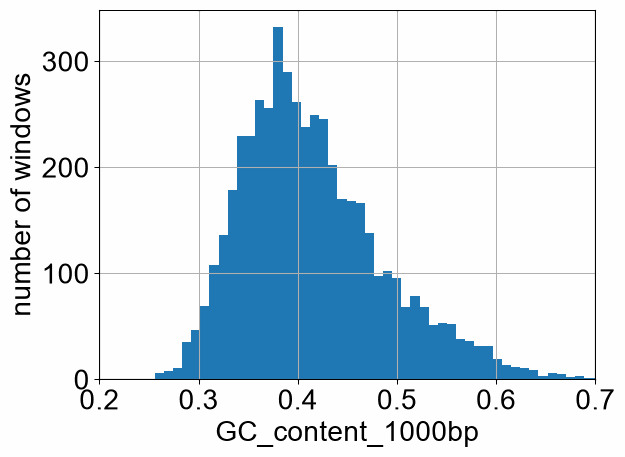

In [6]:
STRINGENT_WINDOWS[FEATURE_GC_CONTENT].hist(bins=50)
plt.xlim(0.2, 0.7)
plt.ylabel('number of windows')
plt.xlabel(FEATURE_GC_CONTENT)

## A note on the lambda_s values of the stringent truth set, and its size

In [7]:
# The lambda_s values quoted in the above dataframe result from intersecting the intervals of the dataframe with another set of intervals for which Nurdan computed lambda_s values. 
# Therefore, the lambda_s values could differ from the values they would have if computed directly from the intervals in the dataframe. 
# Nurdan actually computed the lambda_s values for the intervals in the dataframe: https://mail.google.com/mail/u/0/#inbox/FFNDWMQPDcdxzXJBLRCpsrzbRcSnftML 
# Ideally, the lambda_s values in this dataframe would be replaced by the values Nurdan computed precisely for the intervals in this dataframe; see TODO in papers/neutral_models_are_biased/8.labeled-enhancers/main.2.ipynb
# This might result in an approximately 2x increase in the number of stringent windows.

## Lax truth sets 

c.f., papers/neutral_models_are_biased/7.CDTS/main.2.ipynb 

### Lax truth set to evaluate Gnocchi

Non-exonic Chen windows, with Gnocchi, and various features (e.g. GC content), and enhancer-overlap status 

In [8]:
def get_chen_windows(): 
    df = pl.read_csv(
        f'{CONSTRAINT_TOOLS_DATA}/chen-et-al-2023-published-version/41586_2023_6045_MOESM4_ESM/Supplementary_Data_2.features.constraint_scores.bed',
        separator='\t',
    )
    df = df.to_pandas()
    return df 
    
LAX_CHEN_WINDOWS = get_chen_windows()
LAX_CHEN_WINDOWS

        chrom      start        end   gnocchi  N_observed  \
0        chr1    1432000    1433000  4.299894         259   
1        chr1    1451000    1452000  0.666316         291   
2        chr1    1453000    1454000  0.828398         256   
3        chr1    1458000    1459000 -0.086128         272   
4        chr1    1463000    1464000  2.948188         191   
...       ...        ...        ...       ...         ...   
1003222  chr9  137262000  137263000 -2.396149         302   
1003223  chr9  137268000  137269000  3.640544         212   
1003224  chr9  137269000  137270000  5.276351         209   
1003225  chr9  137275000  137276000  2.687348         290   
1003226  chr9  137290000  137291000  2.162811         223   

         window overlaps enhancer  window overlaps merged_exon      B  \
0                            True                        False  0.653   
1                           False                        False  0.652   
2                           False               

Text(0.5, 0, 'GC_content_1000bp')

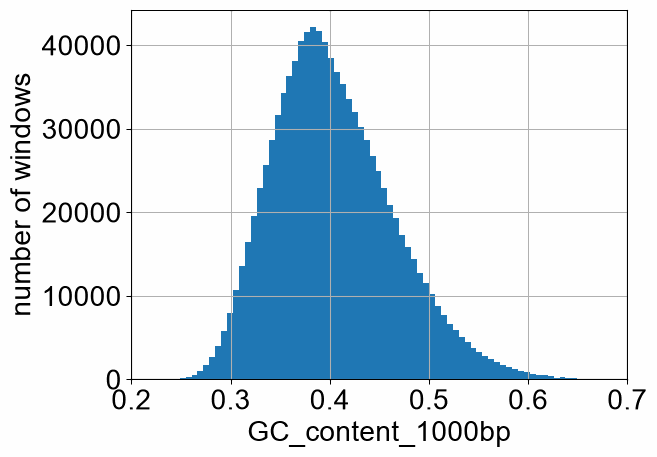

In [9]:
LAX_CHEN_WINDOWS[FEATURE_GC_CONTENT].hist(bins=100)
plt.xlim(0.2, 0.7)
plt.ylabel('number of windows')
plt.xlabel(FEATURE_GC_CONTENT)

### Lax truth set to evaluate lambda_s 

Non-exonic Chen windows, with lambda_s (Dukler et al), and various features (e.g. GC content), and enhancer-overlap status 

In [10]:
def get_chen_windows_with_lambda_s(): 
    # https://mail.google.com/mail/u/0/#inbox/QgrcJHrjCsBTxVdFdTZvkMTlDfGKRnDvZxl
    # http://compgen.cshl.edu/extrainsight/description.php
    df = pl.read_csv(
        f'{CONSTRAINT_TOOLS_DATA}/lambda_s/Results_26July2024.csv',
        infer_schema_length=1000000,
    )
    df = df.with_columns(
        df["start"].cast(pl.Int64),
        df["end"].cast(pl.Int64),
    )
    df = df.to_pandas()

    # Nurdan: "I've included the windows for which ExtRaINSIGHT does not report results, 
    # as they do not pass the filtering steps. 
    # In these cases, all values from columns 4 to 9 are 0."
    df = df[df['num_possible_mutations'] > 0]

    df = LAX_CHEN_WINDOWS.merge(df, left_on=['chrom', 'start', 'end'], right_on=['chr', 'start', 'end'], how='inner')
    df = df.drop(columns=['chr'])

    return df 
    
LAX_CHEN_WINDOWS_WITH_LAMBDA_S = get_chen_windows_with_lambda_s()
LAX_CHEN_WINDOWS_WITH_LAMBDA_S

       chrom      start        end   gnocchi  N_observed  \
0       chr1    1432000    1433000  4.299894         259   
1       chr1    1451000    1452000  0.666316         291   
2       chr1    1453000    1454000  0.828398         256   
3       chr1    1458000    1459000 -0.086128         272   
4       chr1    1463000    1464000  2.948188         191   
...      ...        ...        ...       ...         ...   
932817  chr9  137262000  137263000 -2.396149         302   
932818  chr9  137268000  137269000  3.640544         212   
932819  chr9  137269000  137270000  5.276351         209   
932820  chr9  137275000  137276000  2.687348         290   
932821  chr9  137290000  137291000  2.162811         223   

        window overlaps enhancer  window overlaps merged_exon      B  \
0                           True                        False  0.653   
1                          False                        False  0.652   
2                          False                        False  

### Lax truth set to evaluate Depletion Rank 

Non-exonic Halldorsson windows, with Depletion Rank score, and various features (e.g. GC content), and enhancer-overlap status 

In [11]:
def get_halldorsson_windows(): 
    df = pl.read_csv(
        f'{CONSTRAINT_TOOLS_DATA}/depletion_rank_scores/41586_2022_4965_MOESM3_ESM.noncoding.enhancer.BGS.gBGC.GC_content.bed', 
        separator='\t'
    )
    df = df.with_columns((1-pl.col('depletion_rank')).alias('depletion_rank_constraint_score_complement'))
    df = df.to_pandas()
    return df

LAX_HALLDORSSON_WINDOWS = get_halldorsson_windows()
LAX_HALLDORSSON_WINDOWS

         chromosome      start        end  depletion_rank  enhancer_overlap  \
0              chr1    1382950    1383450        0.637265             500.0   
1              chr1    1383000    1383500        0.696719             500.0   
2              chr1    1383050    1383550        0.856514             500.0   
3              chr1    1383100    1383600        0.848593             499.0   
4              chr1    1383150    1383650        0.940270             449.0   
...             ...        ...        ...             ...               ...   
38632861       chr9  137985250  137985750        0.162180               NaN   
38632862       chr9  137985300  137985800        0.103548               NaN   
38632863       chr9  137985350  137985850        0.137103               NaN   
38632864       chr9  137985400  137985900        0.192227               NaN   
38632865       chr9  137985450  137985950        0.125230               NaN   

          window overlaps enhancer      B  B_M1star

### Lax truth set to evaluate CDTS 
Non-exonic CDTS windows, with CDTS score, and various features (e.g. GC content), and enhancer-overlap status 

In [12]:
def get_CDTS_windows():
    df = pl.read_csv(
        f'{CONSTRAINT_TOOLS_DATA}/CDTS/CDTS.gnomAD.hg38.noncoding.enhancer.BGS.gBGC.GC_content.bed', 
        separator='\t'
    )
    df = df.with_columns((100-pl.col('percentile_rank_of_observed_minus_expected')).alias('percentile_rank_of_observed_minus_expected_complement'))
    df = df.to_pandas()
    return df

LAX_CDTS_WINDOWS = get_CDTS_windows()
LAX_CDTS_WINDOWS

          chromosome     start       end  observed_counts  expected_counts  \
0               chr1   1382859   1383410               10        12.150556   
1               chr1   1382869   1383420               10        12.163989   
2               chr1   1382879   1383430               10        12.142615   
3               chr1   1382889   1383440                9        12.162707   
4               chr1   1382899   1383450                9        11.994043   
...              ...       ...       ...              ...              ...   
193455898      chr17  58762584  58763135               16        16.767538   
193455899      chr17  58762594  58763145               16        16.734729   
193455900      chr17  58762604  58763155               16        16.730413   
193455901      chr17  58762614  58763165               16        16.701082   
193455902      chr17  58762624  58763175               16        16.738258   

           observed_minus_expected  \
0                        

## Mapping constraint metrics onto dataframes, and columns in those dataframes

In [13]:
ARGS = {
    'gnocchi': { 
        'constraint_score_lax': 'gnocchi',
        'constraint_score_stringent': 'gnocchi',
        'constraint_score_alias': 'Gnocchi',
        'df_lax': LAX_CHEN_WINDOWS,
    },
    'lambda_s': { 
        'constraint_score_lax': 'strong_selection',
        'constraint_score_stringent': 'lambda_s',
        'constraint_score_alias': 'lambda_s',
        'df_lax': LAX_CHEN_WINDOWS_WITH_LAMBDA_S,
    }, 
    'depletion_rank': {
        'constraint_score_lax': 'depletion_rank_constraint_score_complement',
        'constraint_score_stringent': 'depletion_rank_constraint_score_complement',
        'constraint_score_alias': 'Depletion Rank',
        'df_lax': LAX_HALLDORSSON_WINDOWS,
    },
    'CDTS': {
        'constraint_score_lax': 'percentile_rank_of_observed_minus_expected_complement',
        'constraint_score_stringent': 'percentile_rank_of_observed_minus_expected_complement',
        'constraint_score_alias': 'CDTS',
        'df_lax': LAX_CDTS_WINDOWS,
    },
}

## Comparing the bootstrap distribution of auPRC, and difference in auPRC between complementary feature bins, for stringent vs lax truth sets

In [14]:
import warnings

def downsample(df, group_columns, target):
  positive_class_sizes = (
    df
    .groupby(group_columns, observed=False)[target]
    .apply(lambda ser: ser.value_counts().get(True, 0))
  )
  negative_class_sizes = (
    df
    .groupby(group_columns, observed=False)[target]
    .apply(lambda ser: ser.value_counts().get(False, 0)) 
  ) 
  positive_to_negative_ratios = positive_class_sizes/negative_class_sizes
  min_positive_to_negative_ratio = positive_to_negative_ratios.min()

  def downsample_positive_class(group):
    negative_class = group[group[target] == False]
    negative_class_size = len(negative_class)
    positive_class = group[group[target] == True]
    new_positive_class_size = int(min_positive_to_negative_ratio*negative_class_size)
    positive_class_downsampled = positive_class.sample(new_positive_class_size, random_state=None) 
    return pd.concat([positive_class_downsampled, negative_class])
  
  with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    df_downsampled = (
      df
      .groupby(group_columns, observed=False)  
      .apply(downsample_positive_class) # elicits DeprecationWarning
      .reset_index(drop=True)
    )
  
  return df_downsampled

def shuffle_bin_downsample(df, feature, target, feature_bins): 
    df = df.copy() 

    df = df.sample(frac=1, replace=True, random_state=None) # shuffle 

    # https://pandas.pydata.org/docs/reference/api/pandas.cut.html
    df[f'{feature}_bin'] = pd.cut(df[f'{feature}'], feature_bins) 

    df = downsample(
        df, 
        group_columns=[f'{feature}_bin'], 
        target=target
    )

    return df

In [15]:
# this is "r" in the baseline-classifier theory: 
def compute_positive_fraction(df, target):
    value_counts = df[target].value_counts()
    number_negative_examples = value_counts.get(False, 0)
    number_positive_examples = value_counts.get(True, 0)
    return number_positive_examples / (number_negative_examples + number_positive_examples)

(np.float64(1.3160143247609286), -0.01476582934621994)

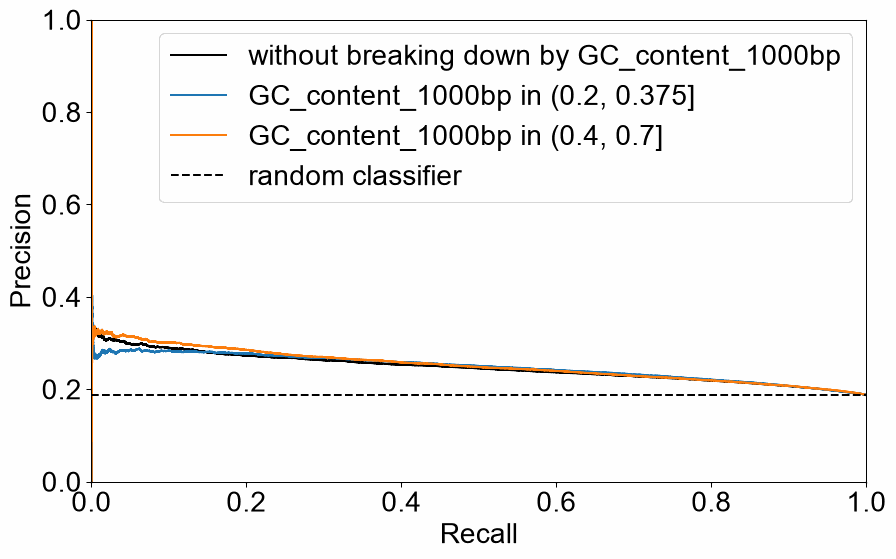

In [16]:
from sklearn.metrics import precision_recall_curve, auc

def compute_area(df, target, constraint_score, ax_pr=None, color=None, label=None): 
    targets, scores = df[target], df[constraint_score]
    precision, recall, _ = precision_recall_curve(targets, scores)
    if ax_pr: ax_pr.plot(recall, precision, linestyle='-', color=color, label=label) 
    return auc(recall, precision)

def compute_area_for_bin(df, feature, feature_bin, target, constraint_score, ax_pr=None, color=None, label=None): 
    df_bin = df[df[f'{feature}_bin'] == feature_bin]

    if len(df_bin) < THRESHOLD_BIN_SIZE: 
        raise ValueError(f'Number of windows in {feature_bin} too small: {len(df_bin)}')

    return compute_area(df_bin, target, constraint_score, ax_pr, color, label)

def compute_auPRCnorm_and_delta(constraint_score, df, feature, feature_bins, target, debug): 
    if len(feature_bins) != 2:
        raise ValueError('Only two feature bins allowed')

    df = shuffle_bin_downsample(df, feature, target, feature_bins)

    if debug: 
        fig, ax_pr = plt.subplots(figsize=(10, 6))
        area = compute_area(df, target, constraint_score, ax_pr, color='black', label=f'without breaking down by {feature}') 
        area_bin_0 = compute_area_for_bin(df, feature, feature_bins[0], target, constraint_score, ax_pr, color=None, label=f'{feature} in {feature_bins[0]}')
        area_bin_1 = compute_area_for_bin(df, feature, feature_bins[1], target, constraint_score, ax_pr, color=None, label=f'{feature} in {feature_bins[1]}')
    else:
        area = compute_area(df, target, constraint_score) # without breaking down by feature
        area_bin_0 = compute_area_for_bin(df, feature, feature_bins[0], target, constraint_score)
        area_bin_1 = compute_area_for_bin(df, feature, feature_bins[1], target, constraint_score)

    r = compute_positive_fraction(df, target)

    if debug: 
        ax_pr.plot([0, 1], [r, r], linestyle='--', color='black', label='random classifier') 
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_xlim(0, 1)
        ax_pr.set_ylim(0, 1)
        ax_pr.legend()

    auPRCnorm = area/r
    delta = (area_bin_0 - area_bin_1)/area

    return auPRCnorm, delta

compute_auPRCnorm_and_delta(
    constraint_score='gnocchi',
    df=LAX_CHEN_WINDOWS, 
    feature=FEATURE_GC_CONTENT,
    feature_bins=FEATURE_BINS_GC_CONTENT,
    target='window overlaps enhancer', # proxy for constraint 
    debug=True
)

(np.float64(1.330808228213771), -0.04456146884450981)

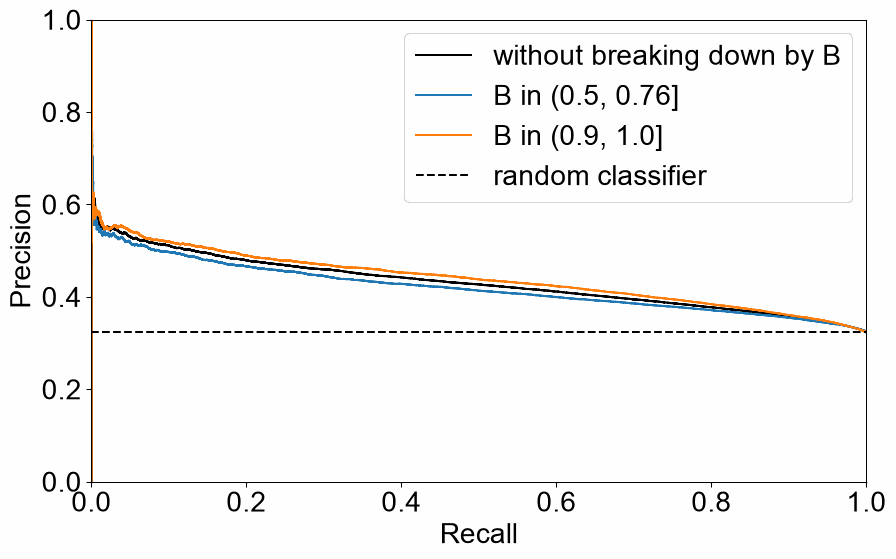

In [17]:
compute_auPRCnorm_and_delta(
    constraint_score='gnocchi',
    df=LAX_CHEN_WINDOWS, 
    feature=FEATURE_BGS,
    feature_bins=FEATURE_BINS_BGS, 
    target='window overlaps enhancer', # proxy for constraint 
    debug=True
)

(np.float64(1.3724755918180434), 0.07550267563011137)

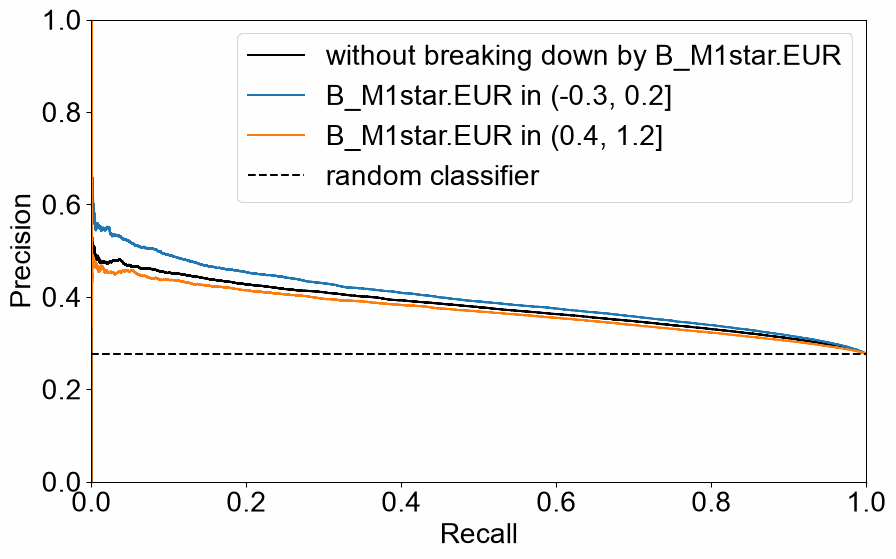

In [18]:
compute_auPRCnorm_and_delta(
    constraint_score='gnocchi',
    df=LAX_CHEN_WINDOWS, 
    feature=FEATURE_GBGC,
    feature_bins=FEATURE_BINS_GBGC, 
    target='window overlaps enhancer', # proxy for constraint 
    debug=True
)

(np.float64(4.317738937965674), 0.11411533756290694)

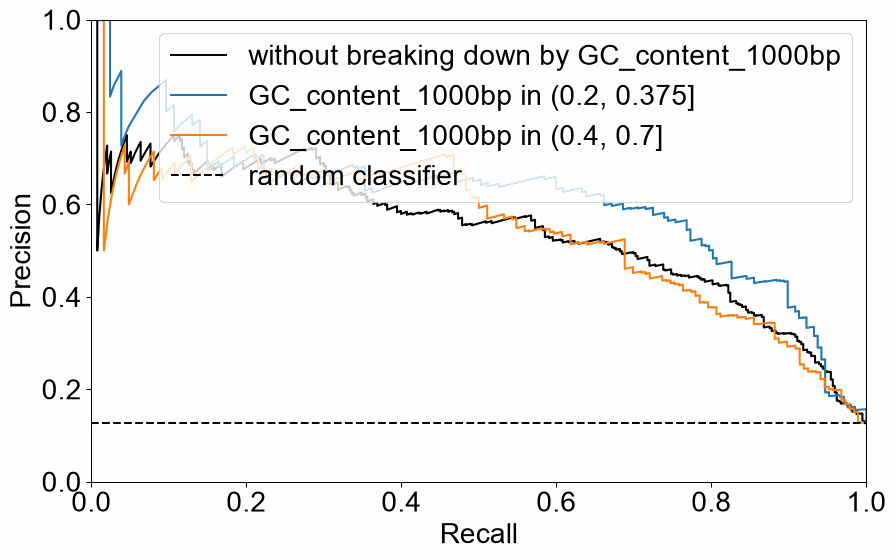

In [19]:
compute_auPRCnorm_and_delta(
    constraint_score='gnocchi',
    df=STRINGENT_WINDOWS, 
    feature=FEATURE_GC_CONTENT,
    feature_bins=FEATURE_BINS_GC_CONTENT,
    target='truly constrained',
    debug=True
)

(np.float64(1.0942449925526303), 0.018519829443849545)

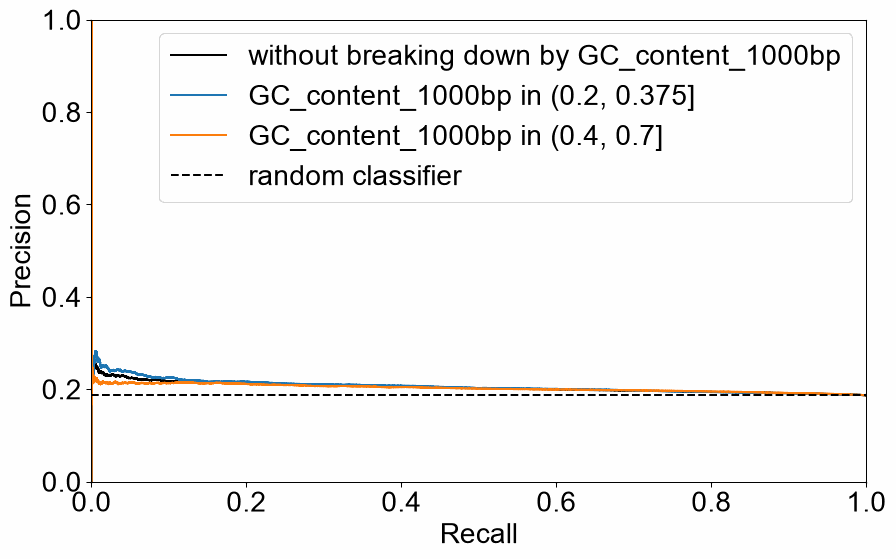

In [20]:
compute_auPRCnorm_and_delta(
    constraint_score='strong_selection', # lambda_s
    df=LAX_CHEN_WINDOWS_WITH_LAMBDA_S, 
    feature=FEATURE_GC_CONTENT,
    feature_bins=FEATURE_BINS_GC_CONTENT,
    target='window overlaps enhancer', # proxy for constraint
    debug=True
)

(np.float64(3.002349584219527), 0.184680597654104)

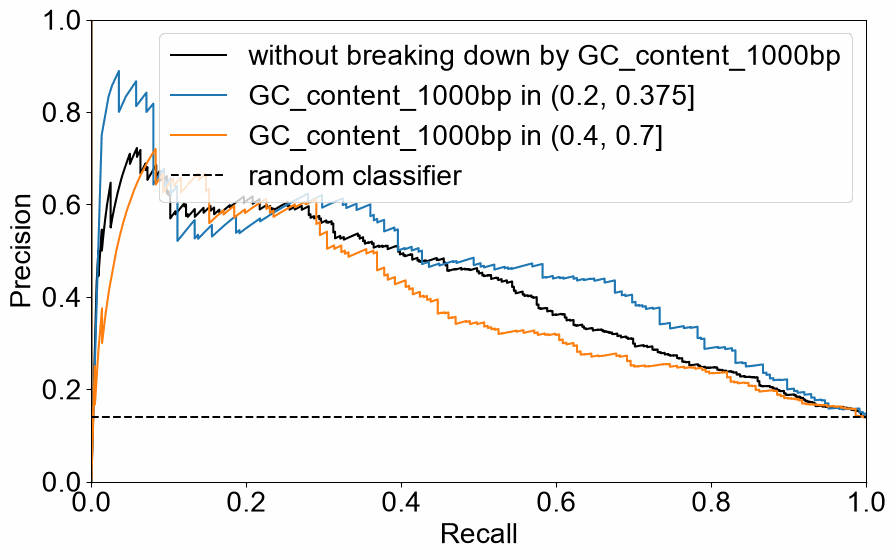

In [21]:
compute_auPRCnorm_and_delta(
    constraint_score='lambda_s',
    df=STRINGENT_WINDOWS, 
    feature=FEATURE_GC_CONTENT,
    feature_bins=FEATURE_BINS_GC_CONTENT,
    target='truly constrained',
    debug=True
)

Plotting gnocchi...


Plotting lambda_s...


Plotting depletion_rank...


Plotting CDTS...


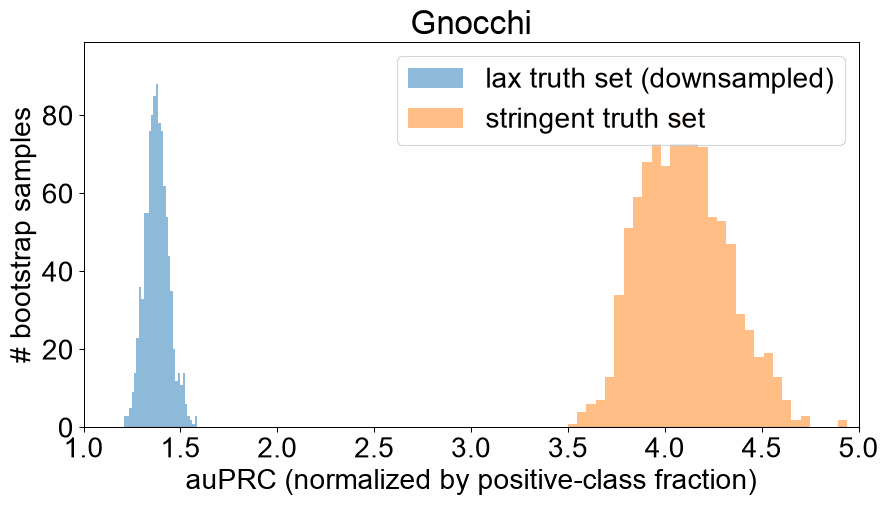

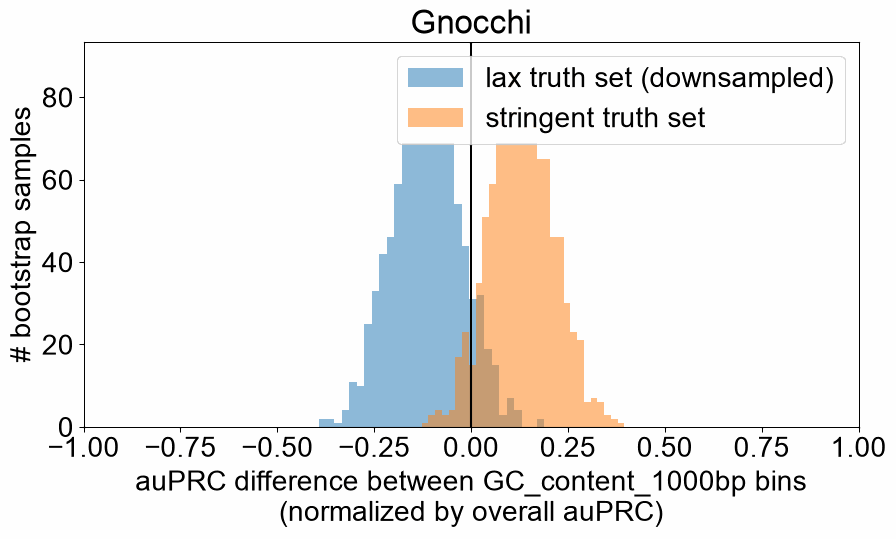

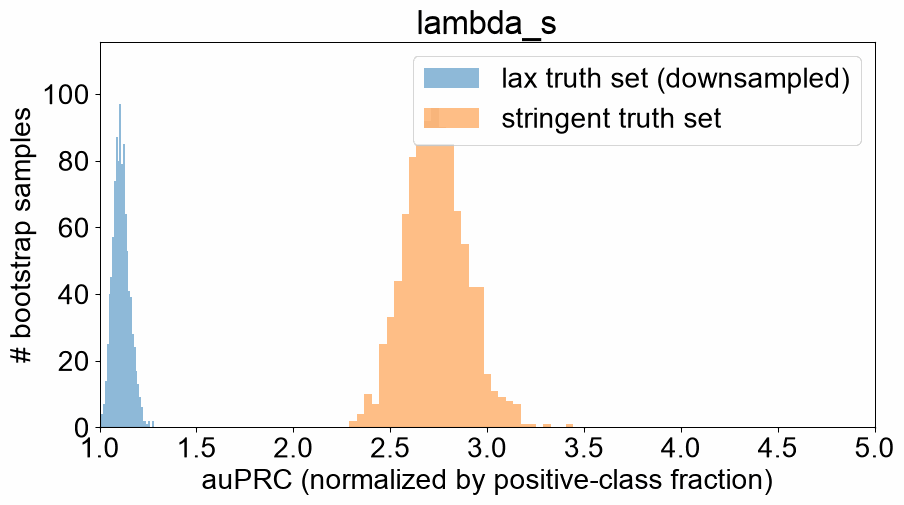

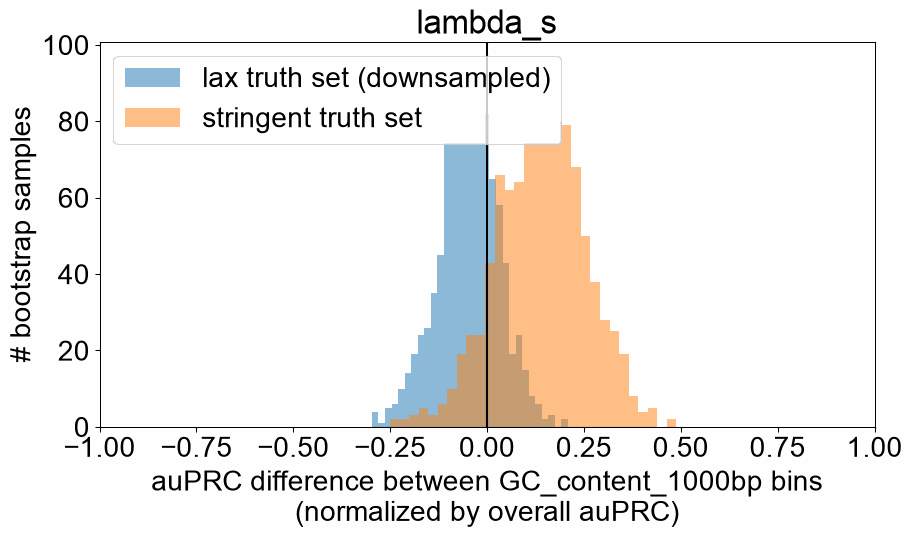

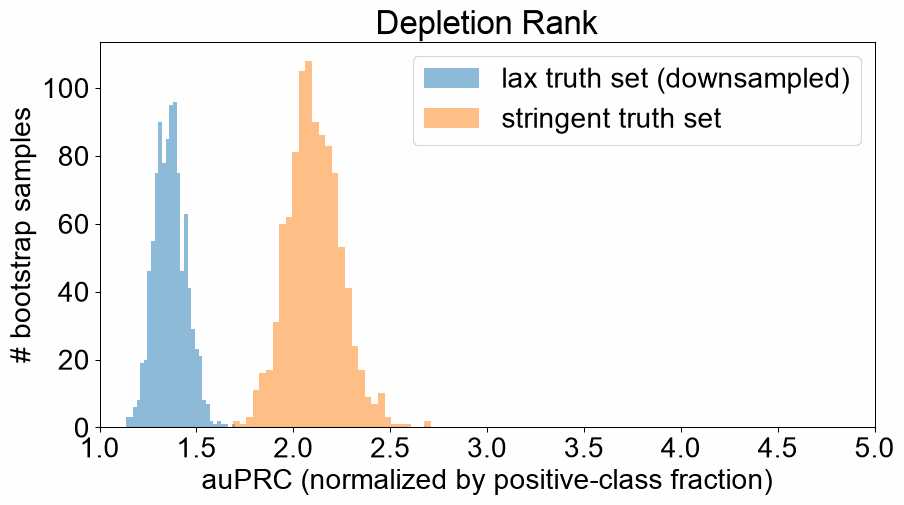

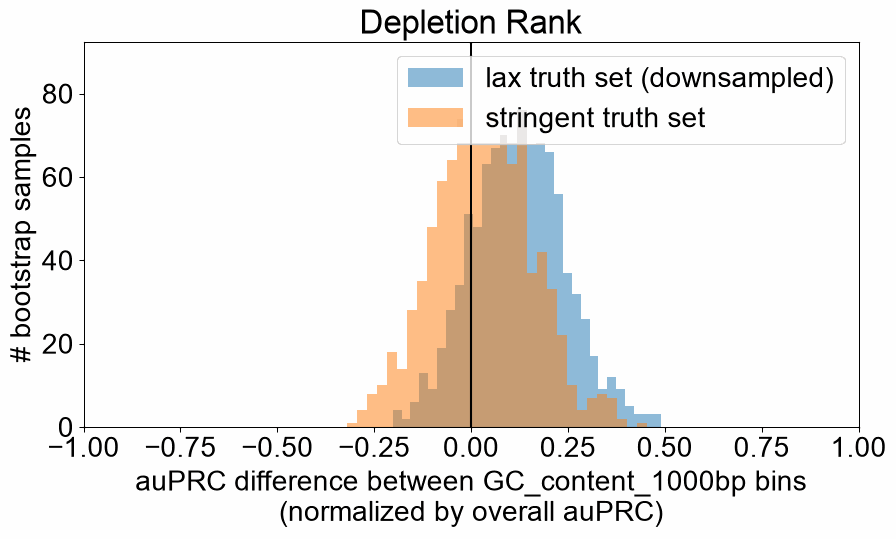

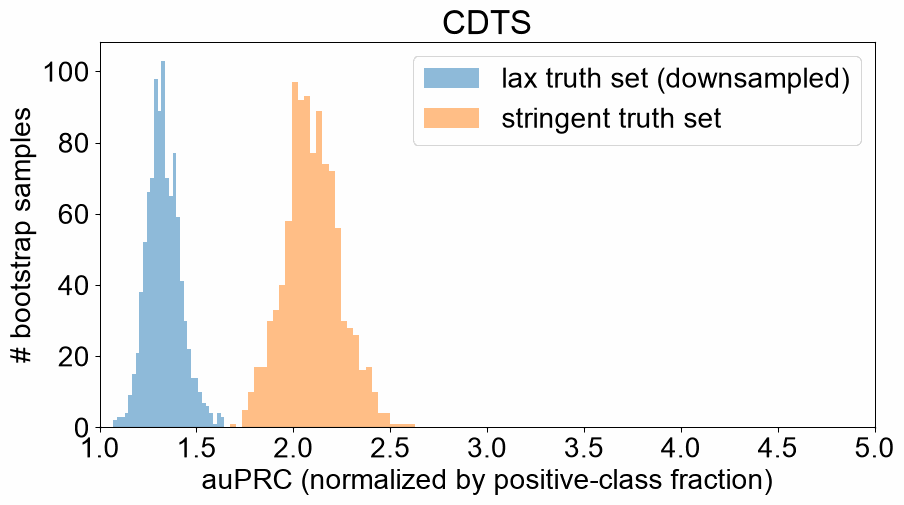

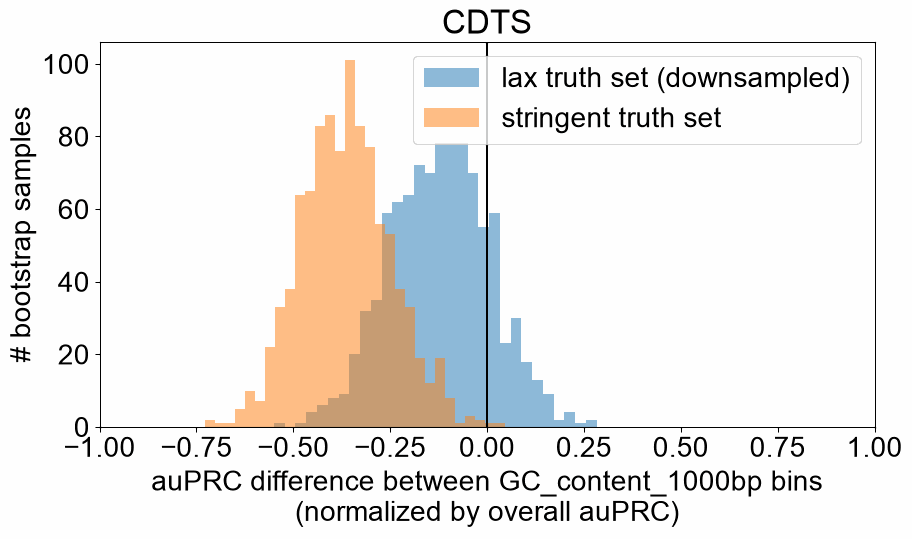

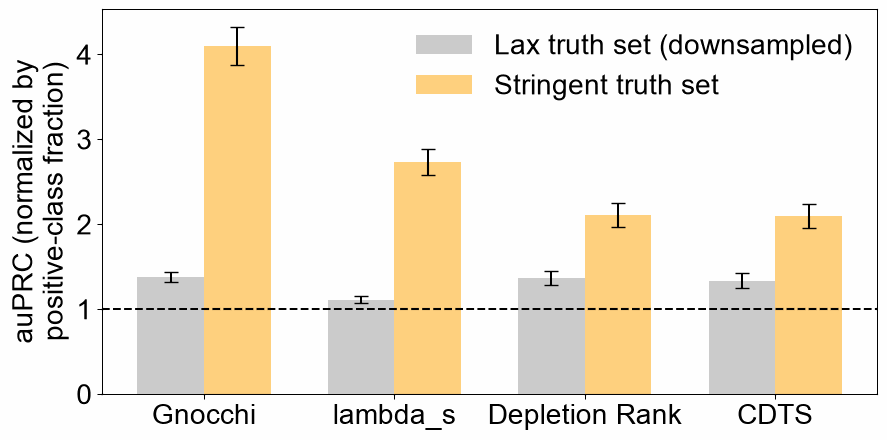

feature used to preprocess windows: GC_content_1000bp
feature: GC_content_1000bp
bins: [(0.2, 0.375), (0.4, 0.7)]
truth set: stringent


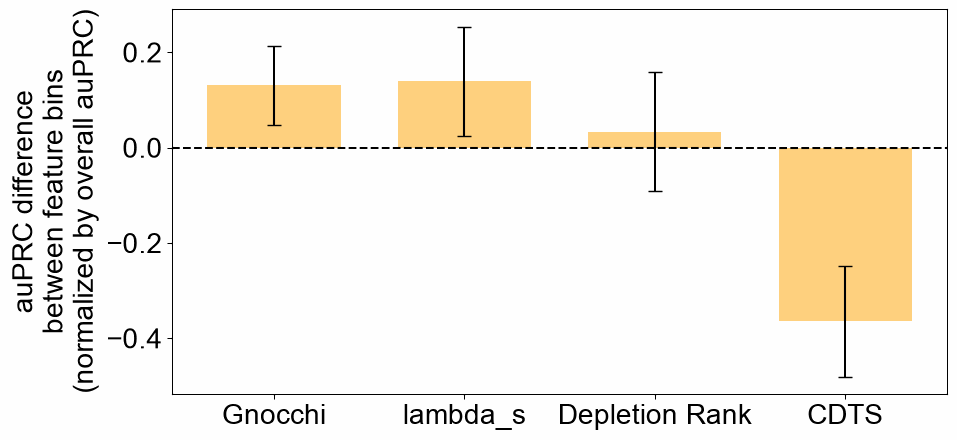

In [22]:
import numpy as np 

def plot_auPRCnorm_and_delta_distributions(ax_auPRCnorm, ax_delta, df, target, feature, feature_bins, constraint_score, label, hist_bins=30, number_bootstraps=1000): 
    auPRCnorms, deltas = [], []

    for _ in range(number_bootstraps):
        auPRCnorm, delta = compute_auPRCnorm_and_delta(constraint_score, df, feature, feature_bins, target, debug=False)
        auPRCnorms.append(auPRCnorm)
        deltas.append(delta)

    ax_auPRCnorm.hist(auPRCnorms, bins=hist_bins, label=label, alpha=0.5)    
    ax_delta.hist(deltas, bins=hist_bins, label=label, alpha=0.5)

    return ( 
        { 'mean': np.mean(auPRCnorms), 'std': np.std(auPRCnorms) }, 
        { 'mean': np.mean(deltas), 'std': np.std(deltas) }
    )

def plot_auPRCnorm_and_delta_distributions_for_lax_vs_stringent_truth_set(feature, feature_bins, args): 
    fig_auPRCnorm, ax_auPRCnorm = plt.subplots(figsize=(10, 5))
    fig_delta, ax_delta = plt.subplots(figsize=(10, 5))

    try: 
        auPRCnorm_lax, delta_lax = plot_auPRCnorm_and_delta_distributions(
            ax_auPRCnorm=ax_auPRCnorm, 
            ax_delta=ax_delta, 
            df=args['df_lax'].sample(n=len(STRINGENT_WINDOWS), random_state=None),
            target='window overlaps enhancer',
            feature=feature,
            feature_bins=feature_bins,
            constraint_score=args['constraint_score_lax'],
            label='lax truth set (downsampled)',
        )
    except ValueError as e: 
        print(f'Skipping lax truth set: {e}')
        auPRCnorm_lax, delta_lax = None, None

    try: 
        auPRCnorm_stringent, delta_stringent = plot_auPRCnorm_and_delta_distributions(
            ax_auPRCnorm=ax_auPRCnorm, 
            ax_delta=ax_delta, 
            df=STRINGENT_WINDOWS,
            target='truly constrained',
            feature=feature,
            feature_bins=feature_bins,
            constraint_score=args['constraint_score_stringent'],
            label='stringent truth set',
        )
    except ValueError as e:
        print(f'Skipping stringent truth set: {e}')
        auPRCnorm_stringent, delta_stringent = None, None
        
    ax_auPRCnorm.set_title(f'{args["constraint_score_alias"]}')
    ax_auPRCnorm.set_xlabel('auPRC (normalized by positive-class fraction)')
    ax_auPRCnorm.set_ylabel('# bootstrap samples')
    ax_auPRCnorm.set_xlim(1, 5)
    ax_auPRCnorm.legend()

    ax_delta.set_title(f'{args["constraint_score_alias"]}')
    ax_delta.set_xlabel(f'auPRC difference between {feature} bins\n(normalized by overall auPRC)')
    ax_delta.set_ylabel('# bootstrap samples')
    ax_delta.set_xlim(-1, 1)
    ax_delta.axvline(x=0, color='black', linestyle='-')
    ax_delta.legend()

    return ( 
        { 'lax': auPRCnorm_lax, 'stringent': auPRCnorm_stringent },
        { 'lax': delta_lax, 'stringent': delta_stringent }
    )

def plot_bar_charts(auPRCnorms, deltas, feature, feature_bins_pretty, plot_deltas_for_both_truth_sets):   
    metrics = list(ARGS.keys())

    lax_auPRCnorm_means = [auPRCnorms[metric]['lax']['mean'] for metric in metrics]
    stringent_auPRCnorm_means = [auPRCnorms[metric]['stringent']['mean'] for metric in metrics]
    lax_delta_means = [deltas[metric]['lax']['mean'] for metric in metrics]
    stringent_delta_means = [deltas[metric]['stringent']['mean'] for metric in metrics]

    lax_auPRCnorm_stds = [auPRCnorms[metric]['lax']['std'] for metric in metrics]
    stringent_auPRCnorm_stds = [auPRCnorms[metric]['stringent']['std'] for metric in metrics]
    lax_delta_stds = [deltas[metric]['lax']['std'] for metric in metrics]
    stringent_delta_stds = [deltas[metric]['stringent']['std'] for metric in metrics]

    x = np.arange(len(metrics))  # the label locations
    width = 0.35  # the width of the bars

    # Determine the two default colors used by matplotlib's bar plots
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_lax = default_colors[0]
    color_stringent = default_colors[1]

    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(x - width/2, lax_auPRCnorm_means, width, label='Lax truth set (downsampled)', yerr=lax_auPRCnorm_stds, capsize=5, color='black', alpha=0.2)
    ax1.bar(x + width/2, stringent_auPRCnorm_means, width, label='Stringent truth set', yerr=stringent_auPRCnorm_stds, capsize=5, color='orange', alpha=0.5)
    ax1.set_ylabel('auPRC (normalized by\npositive-class fraction)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([ARGS[metric]['constraint_score_alias'] for metric in metrics])
    ax1.legend(frameon=False)
    ax1.axhline(y=1, color='black', linestyle='--')
    plt.show()
    print(
        f'feature used to preprocess windows: {feature}'
    )

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    if plot_deltas_for_both_truth_sets: 
        ax2.bar(x - width/2, lax_delta_means, width, label='lax truth set (downsampled)', yerr=lax_delta_stds, capsize=5)
        ax2.bar(x + width/2, stringent_delta_means, width, label='stringent truth set', yerr=stringent_delta_stds, capsize=5)
        ax2.legend()
        print(
            f'feature: {feature}\n'
            f'bins: {feature_bins_pretty}'
        )
    else: 
        ax2.bar(x, stringent_delta_means, 2*width, yerr=stringent_delta_stds, capsize=5, color='orange', alpha=0.5)
        print(
            f'feature: {feature}\n'
            f'bins: {feature_bins_pretty}\n'
            f'truth set: stringent'
        )

    ax2.set_ylabel(f'auPRC difference\nbetween feature bins\n(normalized by overall auPRC)')
    ax2.set_xticks(x)
    ax2.set_xticklabels([ARGS[metric]['constraint_score_alias'] for metric in metrics])
    ax2.axhline(y=0, color='black', linestyle='--')
    plt.show()

def plot_bar_charts_wrapper(feature, feature_bins, plot_deltas_for_both_truth_sets): 
    feature_bins_pretty = [(float(interval.left), float(interval.right)) for interval in feature_bins]

    auPRCnorms, deltas = {}, {}
    for constraint_metric in ARGS.keys():
        print(f'Plotting {constraint_metric}...')
        auPRCnorm, delta = plot_auPRCnorm_and_delta_distributions_for_lax_vs_stringent_truth_set(
            feature, feature_bins, ARGS[constraint_metric]
        )
        auPRCnorms[constraint_metric] = auPRCnorm
        deltas[constraint_metric] = delta
    
    plot_bar_charts(auPRCnorms, deltas, feature, feature_bins_pretty, plot_deltas_for_both_truth_sets)

plot_bar_charts_wrapper(feature=FEATURE_GC_CONTENT, feature_bins=FEATURE_BINS_GC_CONTENT, plot_deltas_for_both_truth_sets=False)

Plotting gnocchi...


Plotting lambda_s...


Plotting depletion_rank...


Plotting CDTS...


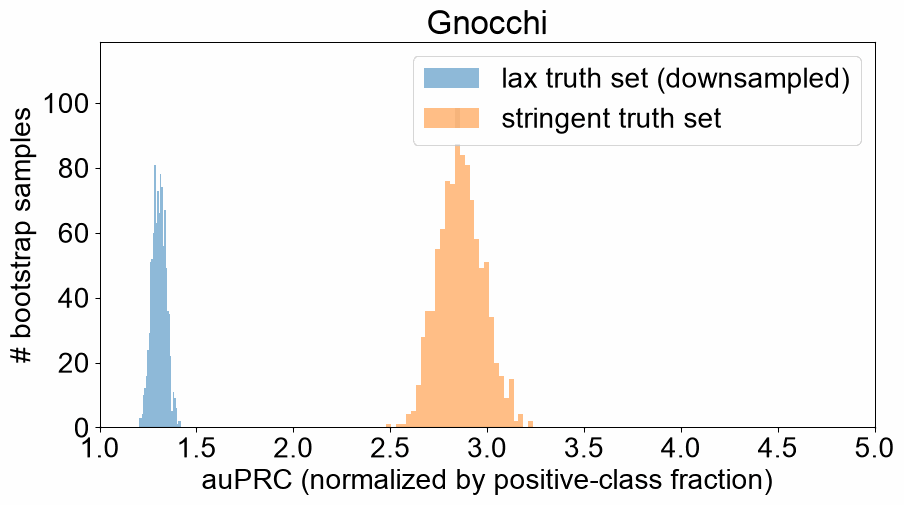

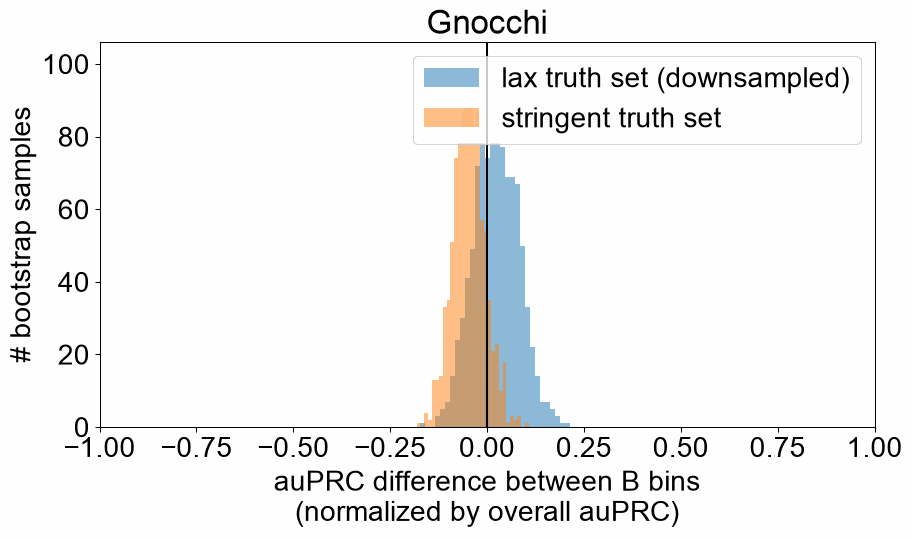

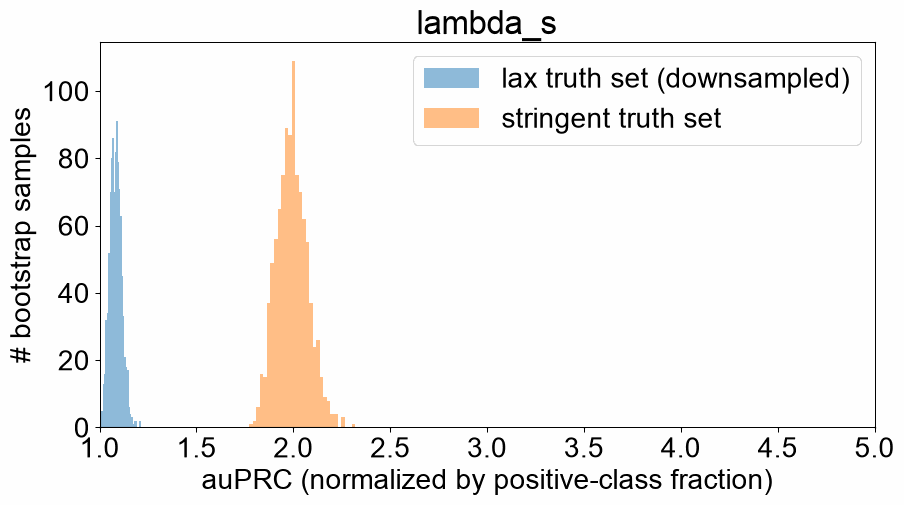

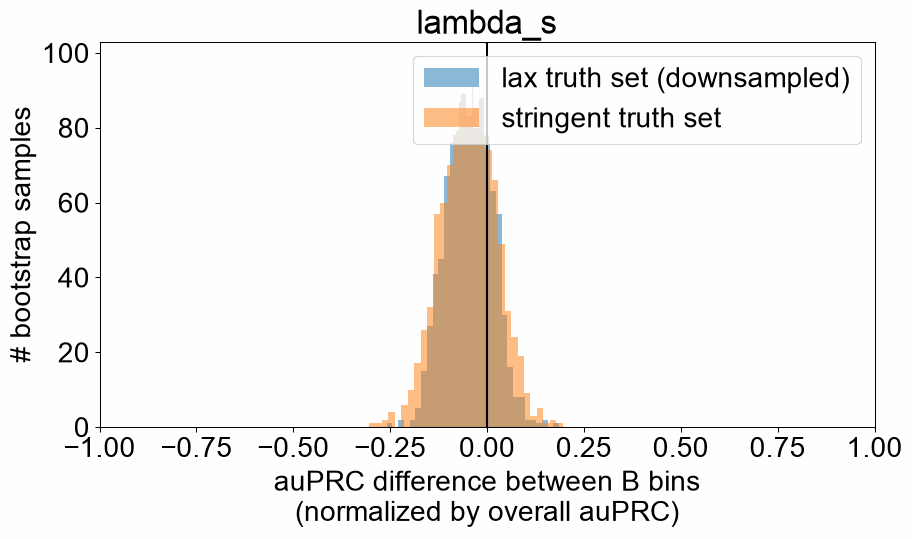

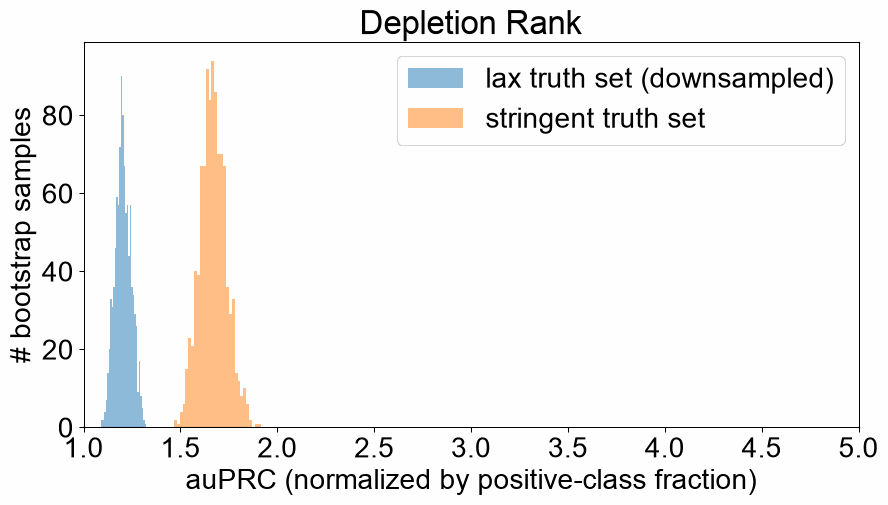

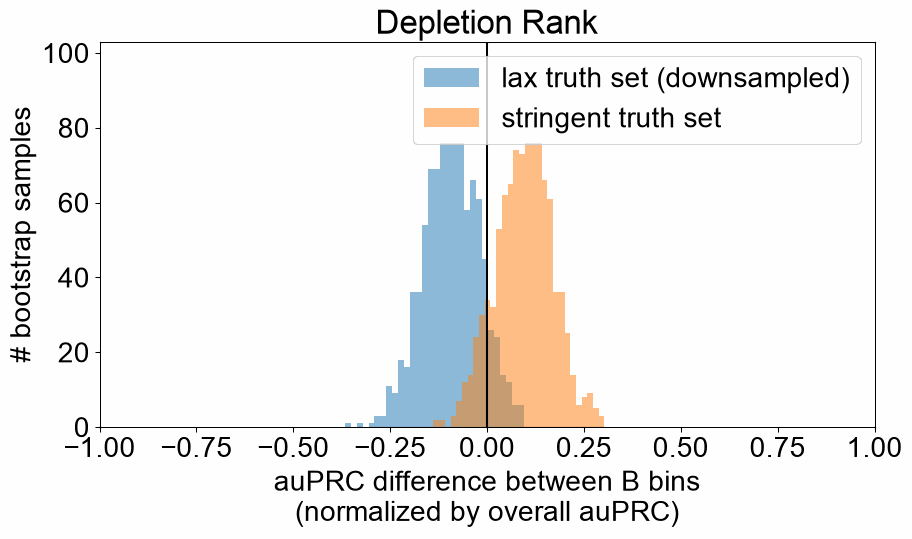

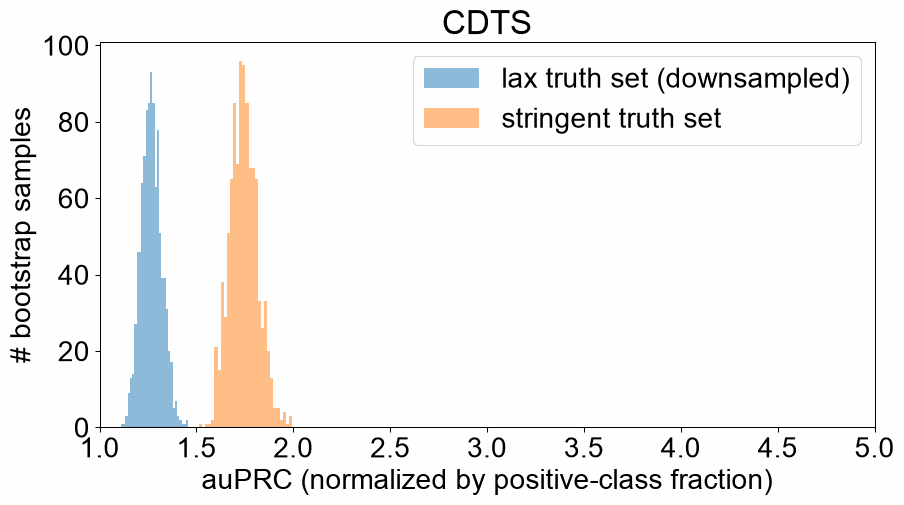

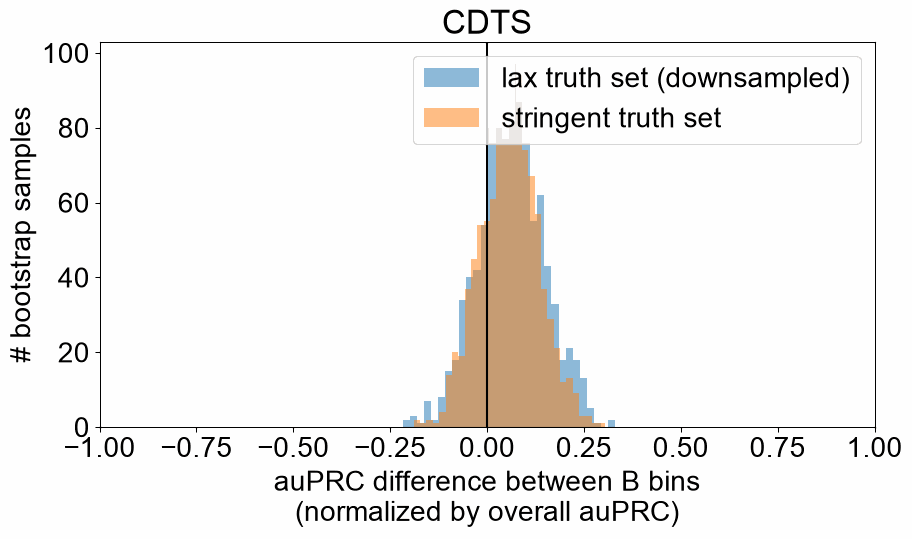

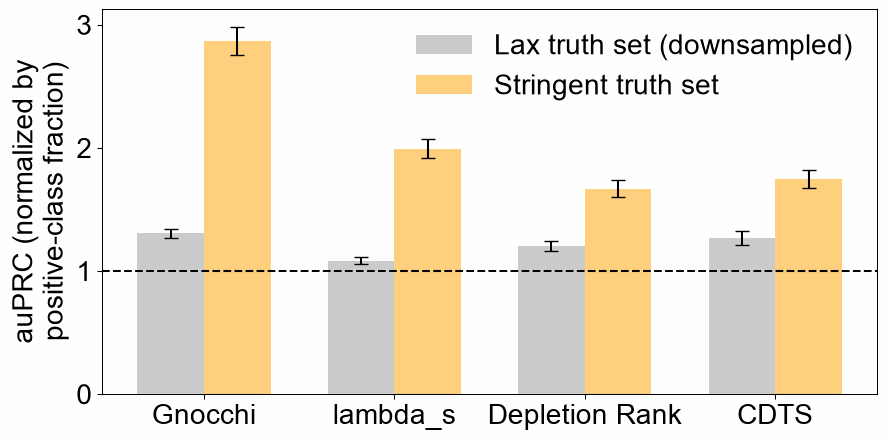

feature used to preprocess windows: B
feature: B
bins: [(0.5, 0.76), (0.9, 1.0)]
truth set: stringent


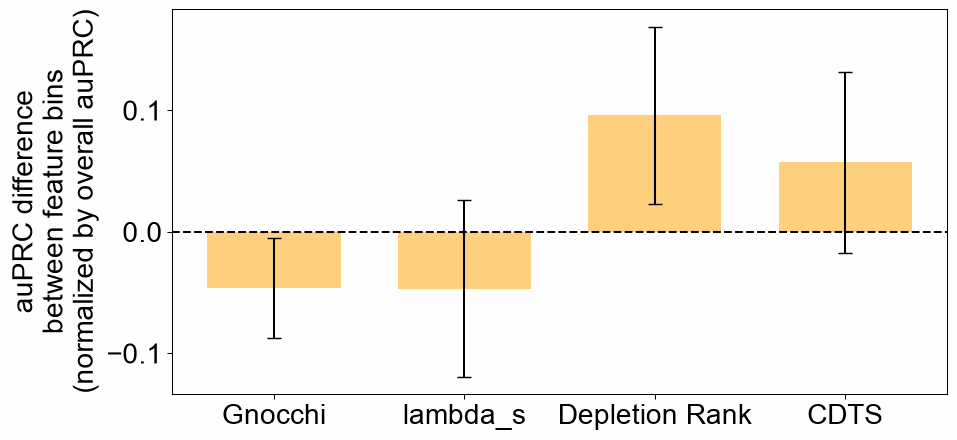

In [23]:
plot_bar_charts_wrapper(feature=FEATURE_BGS, feature_bins=FEATURE_BINS_BGS, plot_deltas_for_both_truth_sets=False)

Plotting gnocchi...


Plotting lambda_s...


Plotting depletion_rank...


Plotting CDTS...


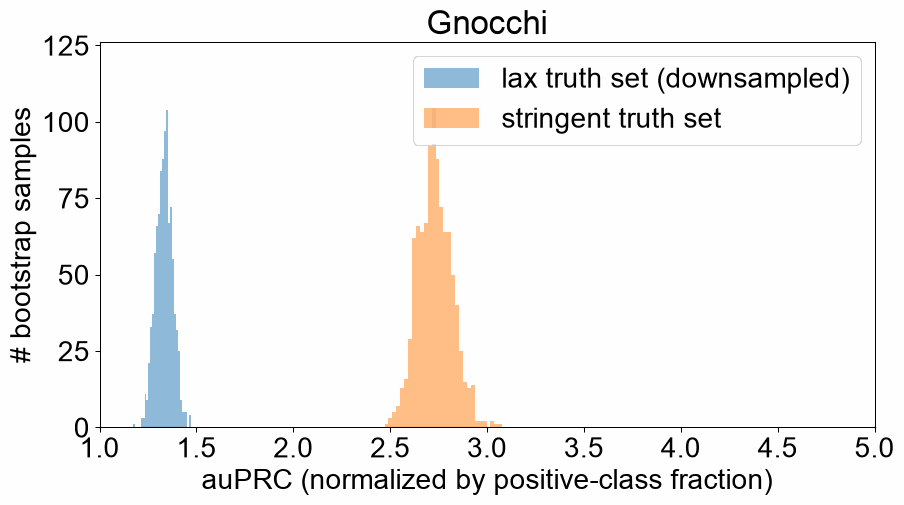

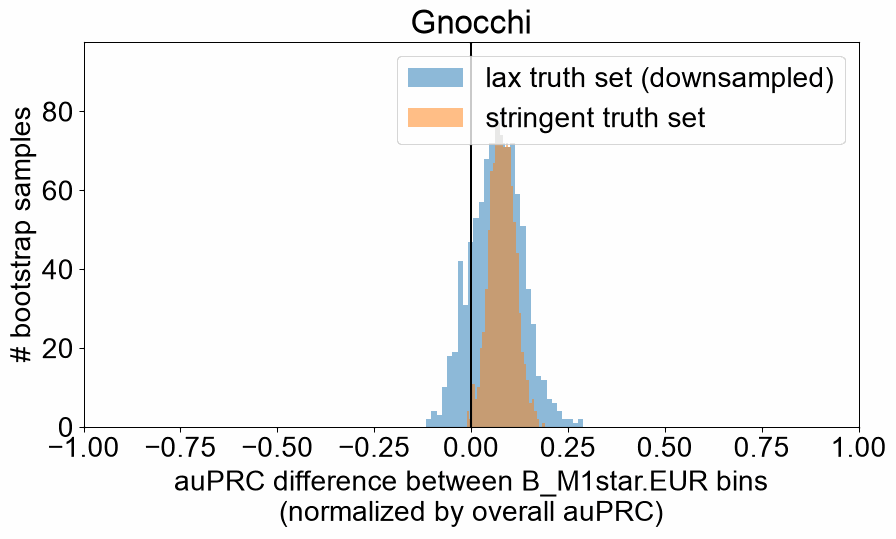

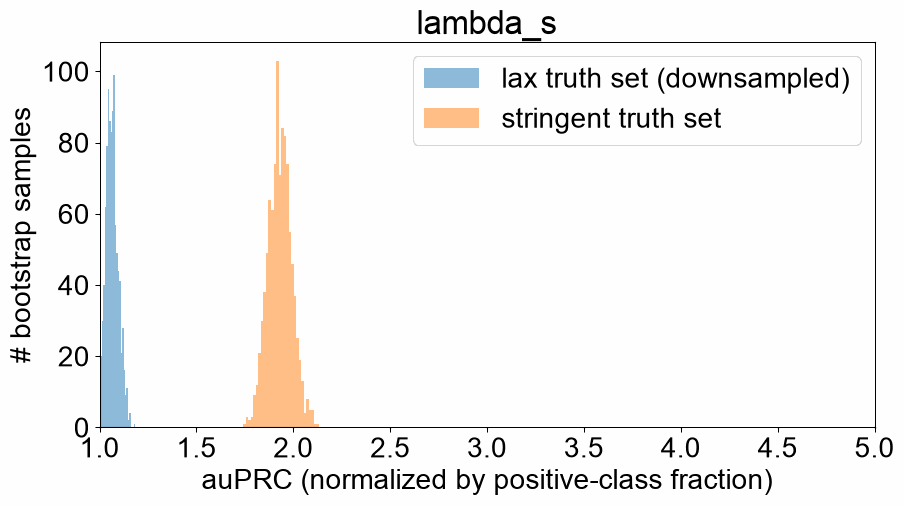

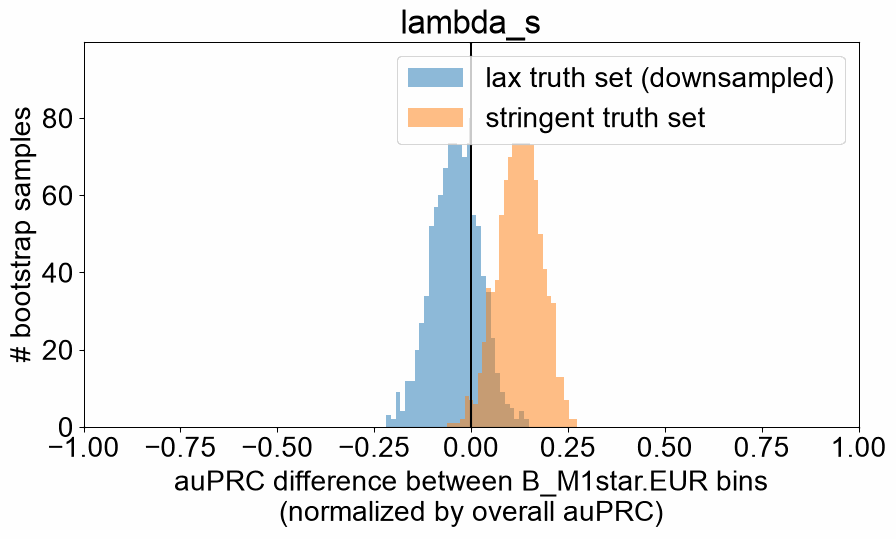

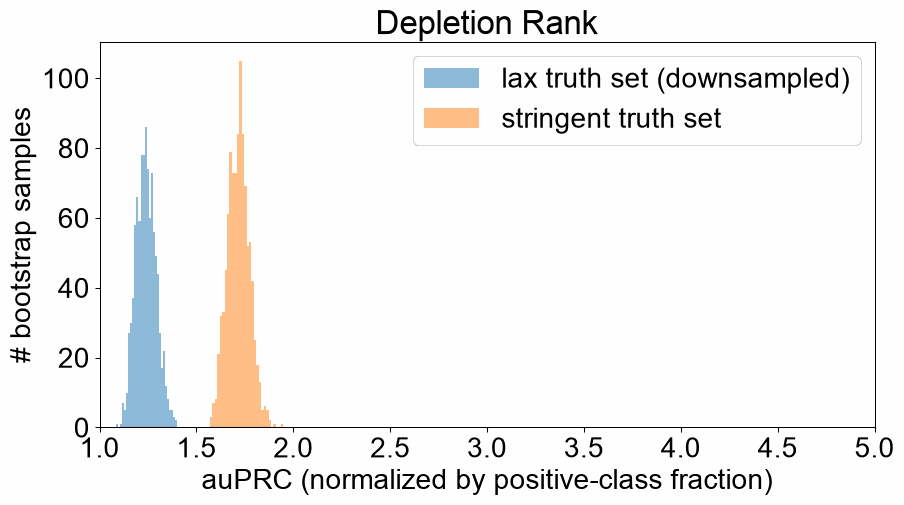

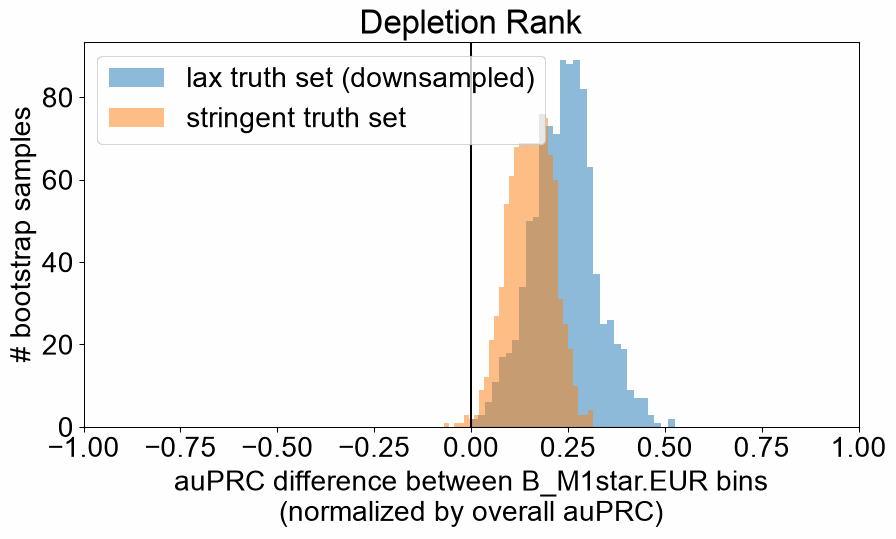

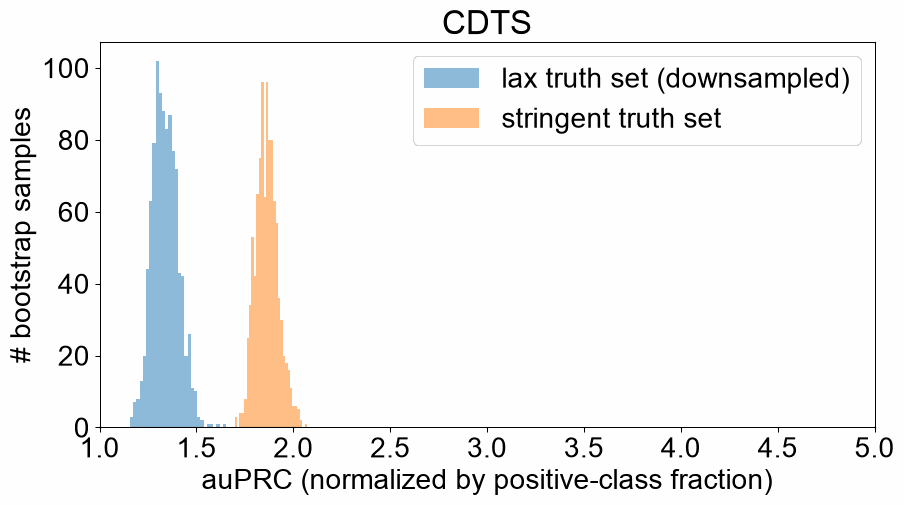

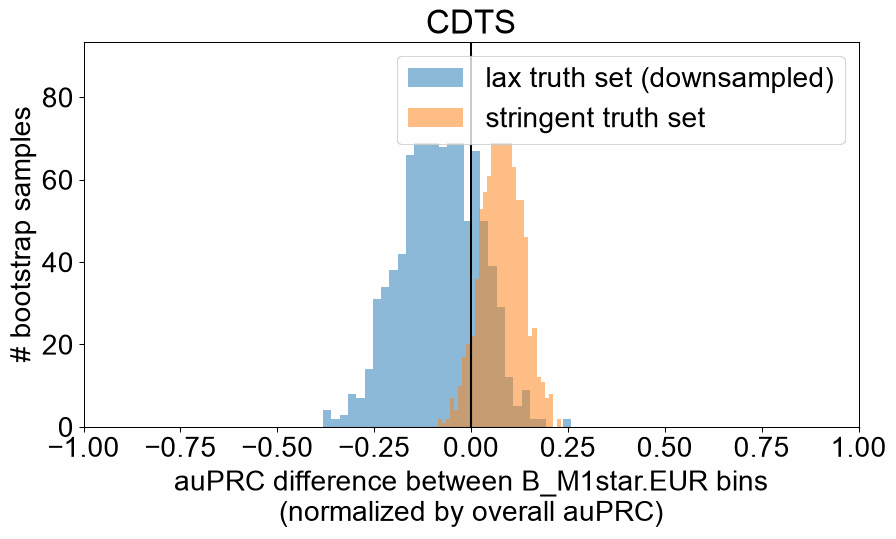

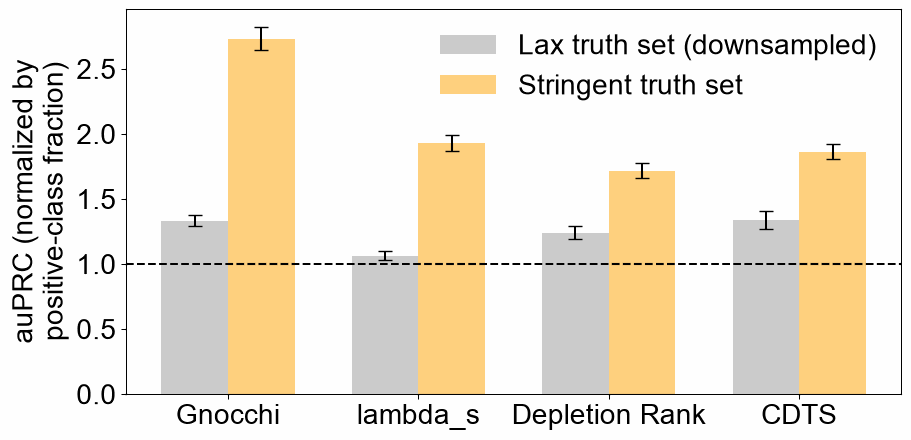

feature used to preprocess windows: B_M1star.EUR
feature: B_M1star.EUR
bins: [(-0.3, 0.2), (0.4, 1.2)]
truth set: stringent


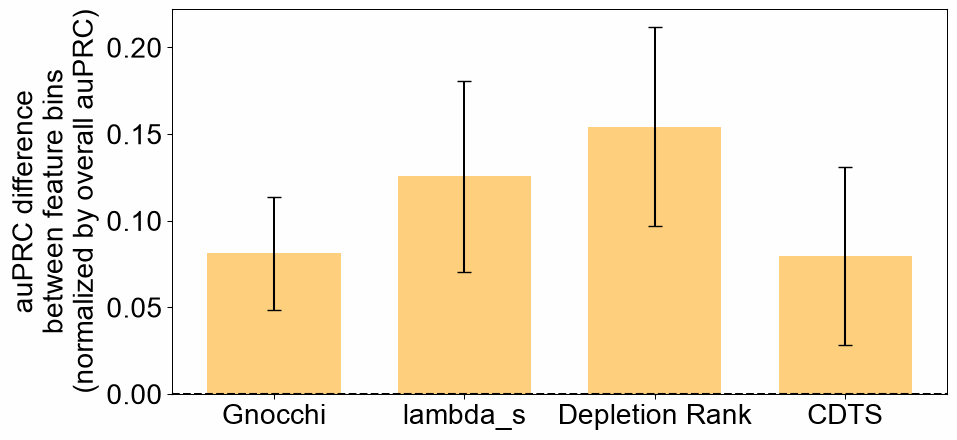

In [24]:
plot_bar_charts_wrapper(feature=FEATURE_GBGC, feature_bins=FEATURE_BINS_GBGC, plot_deltas_for_both_truth_sets=False)

## PREVALENCE CHECK: π, normalized auPRC and auROC, lax against stringent

`downsample` gives the two feature bins a common π within one bootstrap sample, so panel D
is free of the 1/π ceiling. It does not give the *lax and stringent* truth sets a common π:
each is downsampled separately. Normalized auPRC can be at most 1/π, so if the stringent
set ends at a lower π, part of the rise from grey to orange bars in panel C is ceiling.

Each bootstrap sample below is drawn exactly as the published bars' were
(`shuffle_bin_downsample`, the same lax subsample per metric, the same bin-size check), and
records, from that one sample:

* **`positive_fraction`** -- π overall, and in each bin (the two should agree);
* **`auPRCnorm`** -- what panel C plots; its mean should reproduce the published bars;
* **`auPRC_skill`** -- (auPRC − π)/(1 − π): 0 for a random classifier, 1 for a perfect one;
* **`auROC`** -- does not depend on π at all.

If stringent > lax holds on auROC for Gnocchi and λs, the "post-hoc validation of
stringency" stands whatever π did. If it holds on normalized auPRC only, it is the ceiling.


In [25]:
# PREVALENCE CHECK
from sklearn.metrics import roc_auc_score

def compute_prevalence_check(constraint_score, df, feature, feature_bins, target):
    # One bootstrap sample, drawn exactly as compute_auPRCnorm_and_delta draws it
    df = shuffle_bin_downsample(df, feature, target, feature_bins)

    for feature_bin in feature_bins:  # same size check, same exception, as the original
        n = (df[f'{feature}_bin'] == feature_bin).sum()
        if n < THRESHOLD_BIN_SIZE:
            raise ValueError(f'Number of windows in {feature_bin} too small: {n}')

    r = compute_positive_fraction(df, target)
    area = compute_area(df, target, constraint_score)
    return {
        'positive_fraction': r,
        'positive_fraction_bin_0': compute_positive_fraction(df[df[f'{feature}_bin'] == feature_bins[0]], target),
        'positive_fraction_bin_1': compute_positive_fraction(df[df[f'{feature}_bin'] == feature_bins[1]], target),
        'auPRCnorm_ceiling': 1/r,
        'auPRCnorm': area/r,
        'auPRC_skill': (area - r)/(1 - r),
        'auROC': roc_auc_score(df[target], df[constraint_score]),
    }

def run_prevalence_check(feature, feature_bins, number_bootstraps=1000):
    rows = []
    for metric, args in ARGS.items():
        truth_sets = {
            'lax': (args['df_lax'].sample(n=len(STRINGENT_WINDOWS), random_state=None),
                    'window overlaps enhancer', args['constraint_score_lax']),
            'stringent': (STRINGENT_WINDOWS, 'truly constrained', args['constraint_score_stringent']),
        }
        for truth_set, (df, target, constraint_score) in truth_sets.items():
            # As in the original, one undersized bin drops the whole truth set for this metric
            try:
                rows.extend([{
                    'feature': feature,
                    'metric': args['constraint_score_alias'],
                    'truth_set': truth_set,
                    'bootstrap': b,
                    **compute_prevalence_check(constraint_score, df, feature, feature_bins, target),
                } for b in range(number_bootstraps)])
            except ValueError as e:
                print(f'Skipping {metric}, {truth_set} truth set: {e}')
    return pd.DataFrame(rows)

def summarize_prevalence_check(results):
    columns = ['positive_fraction', 'positive_fraction_bin_0', 'positive_fraction_bin_1',
               'auPRCnorm_ceiling', 'auPRCnorm', 'auPRC_skill', 'auROC']
    summary = results.groupby(['metric', 'truth_set'])[columns].agg(['mean', 'std'])
    print(summary.to_string(float_format=lambda x: f'{x:.4f}'))

    # Does stringent beat lax on each measure? Mean difference, and its size in pooled s.d.
    means = results.groupby(['metric', 'truth_set'])[['auPRCnorm', 'auPRC_skill', 'auROC']].mean().unstack('truth_set')
    sds = results.groupby(['metric', 'truth_set'])[['auPRCnorm', 'auPRC_skill', 'auROC']].std().unstack('truth_set')
    print('\nstringent minus lax (mean difference / pooled s.d.)')
    for measure in ['auPRCnorm', 'auPRC_skill', 'auROC']:
        diff = means[measure]['stringent'] - means[measure]['lax']
        pooled = ((sds[measure]['stringent']**2 + sds[measure]['lax']**2)/2)**0.5
        print(f'  {measure}:')
        for metric in diff.index:
            print(f'    {metric:15s} {diff[metric]:+.4f}  ({diff[metric]/pooled[metric]:+.1f} s.d.)')


In [26]:
# PREVALENCE CHECK: GC content, Figure 4C
PREVALENCE_GC = run_prevalence_check(FEATURE_GC_CONTENT, FEATURE_BINS_GC_CONTENT)
summarize_prevalence_check(PREVALENCE_GC)


                         positive_fraction        positive_fraction_bin_0        positive_fraction_bin_1        auPRCnorm_ceiling        auPRCnorm        auPRC_skill         auROC       
                                      mean    std                    mean    std                    mean    std              mean    std      mean    std        mean    std   mean    std
metric         truth_set                                                                                                                                                                  
CDTS           lax                  0.1132 0.0076                  0.1132 0.0076                  0.1131 0.0077            8.8783 0.6071    1.2479 0.0760      0.0316 0.0098 0.5724 0.0139
               stringent            0.1378 0.0087                  0.1379 0.0087                  0.1377 0.0087            7.2872 0.4633    2.0985 0.1404      0.1753 0.0226 0.6766 0.0142
Depletion Rank lax                  0.0975 0.0065                

In [27]:
# PREVALENCE CHECK: BGS, Supporting Figure 5E
PREVALENCE_BGS = run_prevalence_check(FEATURE_BGS, FEATURE_BINS_BGS)
summarize_prevalence_check(PREVALENCE_BGS)


                         positive_fraction        positive_fraction_bin_0        positive_fraction_bin_1        auPRCnorm_ceiling        auPRCnorm        auPRC_skill         auROC       
                                      mean    std                    mean    std                    mean    std              mean    std      mean    std        mean    std   mean    std
metric         truth_set                                                                                                                                                                  
CDTS           lax                  0.2193 0.0102                  0.2194 0.0101                  0.2192 0.0102            4.5703 0.2144    1.2898 0.0646      0.0813 0.0181 0.5513 0.0140
               stringent            0.2682 0.0121                  0.2681 0.0121                  0.2684 0.0121            3.7356 0.1699    1.7457 0.0686      0.2731 0.0249 0.6744 0.0123
Depletion Rank lax                  0.2185 0.0093                

In [28]:
# PREVALENCE CHECK: gBGC, Supporting Figure 5F
PREVALENCE_GBGC = run_prevalence_check(FEATURE_GBGC, FEATURE_BINS_GBGC)
summarize_prevalence_check(PREVALENCE_GBGC)


                         positive_fraction        positive_fraction_bin_0        positive_fraction_bin_1        auPRCnorm_ceiling        auPRCnorm        auPRC_skill         auROC       
                                      mean    std                    mean    std                    mean    std              mean    std      mean    std        mean    std   mean    std
metric         truth_set                                                                                                                                                                  
CDTS           lax                  0.1917 0.0095                  0.1918 0.0095                  0.1916 0.0095            5.2302 0.2603    1.4066 0.0650      0.0963 0.0156 0.5952 0.0127
               stringent            0.2897 0.0112                  0.2898 0.0112                  0.2896 0.0112            3.4571 0.1338    1.8631 0.0569      0.3516 0.0203 0.7200 0.0098
Depletion Rank lax                  0.1849 0.0097                

In [29]:
# PREVALENCE CHECK: keep the raw bootstrap samples, so no rerun is needed to re-read them
pd.concat([PREVALENCE_GC, PREVALENCE_BGS, PREVALENCE_GBGC]).to_csv('prevalence_check.bootstraps.tsv', sep='\t', index=False)
